# Turb-DETR — Week 1: Baseline + Turbidity Collapse Proof

**What this does:**
1. Restructures dataset (symlinks, ~10s)
2. Filters out ROV class (class 2)
3. Creates classes.txt and YAML config
4. Trains RT-DETR-S baseline (30 epochs, ~1.5-2hr)
5. Evaluates on clean test set
6. Generates turbid test images (Jaffe-McGlamery)
7. Evaluates on turbid test sets (3 levels)
8. Prints motivation table
9. Saves everything to Drive

**Requirements:** T4 GPU, ~3 hours total.

**Dataset confirmed:**
- Class 0 = plastic (garbage/debris)
- Class 1 = bio (sea animals, plants)
- Class 2 = rov (FILTERED OUT)


In [1]:
# ============================================================
# CELL 1: GPU check + install + mount Drive
# ============================================================
import torch, os, time
t0 = time.time()

if not torch.cuda.is_available():
    raise RuntimeError("NO GPU — Runtime → Change runtime type → T4 GPU")
print(f"GPU: {torch.cuda.get_device_name(0)}")

!pip install -q ultralytics==8.3.40

from google.colab import drive
drive.mount('/content/drive')

# Dataset path (VERIFIED from exploration)
DATASET = "/content/drive/MyDrive/underwater_datasets/trash_ICRA19/dataset"

# Auto-detect if nested differently
if not os.path.exists(DATASET):
    base = "/content/drive/MyDrive/underwater_datasets"
    for n in os.listdir(base):
        if "icra" in n.lower():
            for sub in ["dataset", "Dataset", ""]:
                cand = os.path.join(base, n, sub) if sub else os.path.join(base, n)
                if os.path.exists(os.path.join(cand, "train")):
                    DATASET = cand
                    break

assert os.path.exists(os.path.join(DATASET, "train")), f"train/ not found in {DATASET}"
print(f"✓ Dataset: {DATASET}")
print(f"  ({time.time()-t0:.1f}s)")


Mounted at /content/drive
✓ Dataset: /content/drive/MyDrive/underwater_datasets/trash_ICRA19/dataset
  (35.3s)


In [2]:
# ============================================================
# CELL 2: Create classes.txt (confirmed from Fulton et al. 2019)
# ============================================================
import os

# Class mapping (confirmed via paper + box count match):
#   0 = plastic (6372 boxes) — matches Fulton's 6339 garbage
#   1 = bio     (2417 boxes) — exact match to Fulton's 2417 sea animals
#   2 = rov     (2278 boxes) — EXCLUDED from training

classes_content = "plastic\nbio\nrov\n"
classes_path = os.path.join(DATASET, "classes.txt")
with open(classes_path, "w") as f:
    f.write(classes_content)
print(f"✓ Created {classes_path}")
print("  0: plastic")
print("  1: bio")
print("  2: rov (will be filtered out)")


✓ Created /content/drive/MyDrive/underwater_datasets/trash_ICRA19/dataset/classes.txt
  0: plastic
  1: bio
  2: rov (will be filtered out)


In [3]:
# ============================================================
# CELL 3: Restructure for Ultralytics + filter out ROV (class 2)
# ============================================================
import os, subprocess, time
from pathlib import Path

t0 = time.time()

SRC = Path(DATASET)
OUT = Path("/content/turb-detr/data/processed")

# First: bulk copy labels to local disk (fast)
LOCAL_LABELS = Path("/content/local_labels")

for split in ["train", "val", "test"]:
    src_dir = SRC / split

    # --- Images: symlink ---
    img_out = OUT / split / "images"
    img_out.mkdir(parents=True, exist_ok=True)
    img_count = 0
    for f in src_dir.glob("*.jpg"):
        dst = img_out / f.name
        if not dst.exists():
            os.symlink(f.resolve(), dst)
        img_count += 1

    # --- Labels: copy to local disk, then filter ROV ---
    local_lbl = LOCAL_LABELS / split
    local_lbl.mkdir(parents=True, exist_ok=True)
    subprocess.run(f"cp {src_dir}/*.txt {local_lbl}/ 2>/dev/null", shell=True)

    lbl_out = OUT / split / "labels"
    lbl_out.mkdir(parents=True, exist_ok=True)

    filtered_count = 0
    rov_removed = 0

    for txt in local_lbl.glob("*.txt"):
        lines_keep = []
        for line in open(txt):
            parts = line.strip().split()
            if len(parts) == 5:
                cls = int(parts[0])
                if cls == 2:  # ROV — skip
                    rov_removed += 1
                    continue
                lines_keep.append(line.strip())

        # Write filtered label
        out_file = lbl_out / txt.name
        with open(out_file, "w") as f:
            f.write("\n".join(lines_keep) + "\n" if lines_keep else "")
        filtered_count += 1

    print(f"  {split}: {img_count} images, {filtered_count} labels, {rov_removed} ROV boxes removed")

# Delete problematic file if it exists
bad_file = OUT / "train" / "images" / "obj1658_frame0002383 (1).jpg"
if bad_file.exists() or bad_file.is_symlink():
    os.unlink(bad_file)
    print("  ✓ Removed problematic file with space in name")

print(f"\n✓ Dataset restructured + ROV filtered ({time.time()-t0:.1f}s)")
print(f"  Images: symlinked from Drive (fast)")
print(f"  Labels: copied to local disk + filtered (no Drive I/O during training)")


  train: 5723 images, 5723 labels, 1802 ROV boxes removed
  val: 820 images, 820 labels, 141 ROV boxes removed
  test: 1144 images, 1144 labels, 335 ROV boxes removed

✓ Dataset restructured + ROV filtered (3034.7s)
  Images: symlinked from Drive (fast)
  Labels: copied to local disk + filtered (no Drive I/O during training)


In [4]:
# ============================================================
# CELL 4: Quick verification — class distribution after filtering
# ============================================================
from pathlib import Path
from collections import Counter

OUT = Path("/content/turb-detr/data/processed")

for split in ["train", "val", "test"]:
    counts = Counter()
    lbl_dir = OUT / split / "labels"
    for txt in lbl_dir.glob("*.txt"):
        for line in open(txt):
            parts = line.strip().split()
            if len(parts) == 5:
                counts[int(parts[0])] += 1

    n_imgs = len(list((OUT / split / "images").glob("*.jpg")))
    print(f"  {split}: {n_imgs} images | plastic={counts.get(0,0)}, bio={counts.get(1,0)}, rov={counts.get(2,0)}")

    if counts.get(2, 0) > 0:
        raise RuntimeError(f"ROV STILL PRESENT in {split}! Filtering failed.")

print("\n✓ No ROV boxes remaining. Dataset clean.")


  train: 5723 images | plastic=4582, bio=1951, rov=0
  val: 820 images | plastic=853, bio=70, rov=0
  test: 1144 images | plastic=937, bio=396, rov=0

✓ No ROV boxes remaining. Dataset clean.


In [5]:
# ============================================================
# CELL 5: Create dataset YAML config
# ============================================================
import yaml, os
from pathlib import Path

config = {
    "path": str(Path("/content/turb-detr/data/processed").resolve()),
    "train": "train/images",
    "val": "val/images",
    "test": "test/images",
    "names": {
        0: "plastic",
        1: "bio",
    }
}

os.makedirs("/content/turb-detr/configs/datasets", exist_ok=True)
yaml_path = "/content/turb-detr/configs/datasets/trash_icra19.yaml"
with open(yaml_path, "w") as f:
    yaml.dump(config, f, default_flow_style=False)

print(f"✓ Config saved: {yaml_path}")
print(open(yaml_path).read())


✓ Config saved: /content/turb-detr/configs/datasets/trash_icra19.yaml
names:
  0: plastic
  1: bio
path: /content/turb-detr/data/processed
test: test/images
train: train/images
val: val/images



In [6]:
# ============================================================
# CELL 6: Set all seeds
# ============================================================
import random, numpy as np, torch, os

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
print(f"✓ All seeds = {SEED}")


✓ All seeds = 42


## Training — RT-DETR-S Baseline (30 epochs)
**Estimated: 1.5–2 hours on T4**

This trains on CLEAN data only. No augmentation. This is your control.


In [9]:
# ============================================================
# CELL 7: Train vanilla RT-DETR-S baseline
# ============================================================
import time
from ultralytics import RTDETR

os.chdir("/content/turb-detr")

t0 = time.time()
model = RTDETR("rtdetr-l.pt")

results = model.train(
    data="configs/datasets/trash_icra19.yaml",
    epochs=20,          # ← changed from 30
    imgsz=640,
    batch=16,
    seed=42,
    project="results",
    name="baseline_rtdetr_clean",
    device=0,
    workers=2,
    patience=10,
    verbose=True,
)

train_time = time.time() - t0
print(f"\n{'='*50}")
print(f"✓ TRAINING COMPLETE ({train_time/60:.1f} min)")
print(f"{'='*50}")


100%|██████████| 63.4M/63.4M [00:00<00:00, 71.2MB/s]


New https://pypi.org/project/ultralytics/8.4.37 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: task=detect, mode=train, model=rtdetr-l.pt, data=configs/datasets/trash_icra19.yaml, epochs=20, time=None, patience=10, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=2, project=results, name=baseline_rtdetr_clean, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=42, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None

100%|██████████| 755k/755k [00:00<00:00, 25.7MB/s]


Overriding model.yaml nc=80 with nc=2
WARNING ⚠️ no model scale passed. Assuming scale='l'.

                   from  n    params  module                                       arguments                     
  0                  -1  1     25248  ultralytics.nn.modules.block.HGStem          [3, 32, 48]                   
  1                  -1  6    155072  ultralytics.nn.modules.block.HGBlock         [48, 48, 128, 3, 6]           
  2                  -1  1      1408  ultralytics.nn.modules.conv.DWConv           [128, 128, 3, 2, 1, False]    
  3                  -1  6    839296  ultralytics.nn.modules.block.HGBlock         [128, 96, 512, 3, 6]          
  4                  -1  1      5632  ultralytics.nn.modules.conv.DWConv           [512, 512, 3, 2, 1, False]    
  5                  -1  6   1695360  ultralytics.nn.modules.block.HGBlock         [512, 192, 1024, 5, 6, True, False]
  6                  -1  6   2055808  ultralytics.nn.modules.block.HGBlock         [1024, 192, 1024, 5, 

100%|██████████| 5.35M/5.35M [00:00<00:00, 107MB/s]


...

  0%|          | 0/358 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
      20/20      13.7G     0.2375     0.3144     0.1909         15        640: 100%|██████████| 358/358 [06:34<00:00,  1.10s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 26/26 [00:15<00:00,  1.63it/s]

                   all        820        923      0.469      0.427      0.417      0.301



20 epochs completed in 2.346 hours.
Optimizer stripped from results/baseline_rtdetr_clean/weights/last.pt, 66.1MB
Optimizer stripped from results/baseline_rtdetr_clean/weights/best.pt, 66.1MB

Validating results/baseline_rtdetr_clean/weights/best.pt...
Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
rt-detr-l summary: 502 layers, 31,987,850 parameters, 0 gradients, 103.4 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 26/26 [00:16<00:00,  1.58it/s]


                   all        820        923      0.526      0.438       0.46      0.321
               plastic        819        853       0.85      0.762      0.824      0.591
                   bio         54         70      0.202      0.114     0.0966     0.0514
Speed: 0.2ms preprocess, 14.7ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to results/baseline_rtdetr_clean

✓ TRAINING COMPLETE (177.6 min)


In [10]:
# ============================================================
# CELL 8: Track A — Evaluate on CLEAN test set
# ============================================================
from ultralytics import RTDETR
from pathlib import Path

# Find best weights
BEST = "results/baseline_rtdetr_clean/weights/best.pt"
if not Path(BEST).exists():
    BEST = "results/baseline_rtdetr_clean/weights/last.pt"
    print(f"⚠️ best.pt not found, using last.pt")

model = RTDETR(BEST)
clean_res = model.val(data="configs/datasets/trash_icra19.yaml", split="test", device=0)

clean_map50 = clean_res.box.map50
clean_map50_95 = clean_res.box.map
clean_prec = clean_res.box.mp
clean_rec = clean_res.box.mr

# Per-class AP
clean_ap_per_class = clean_res.box.ap50

print(f"\n{'='*50}")
print(f"TRACK A — CLEAN TEST RESULTS")
print(f"{'='*50}")
print(f"  mAP@0.5:      {clean_map50:.4f}")
print(f"  mAP@0.5:0.95: {clean_map50_95:.4f}")
print(f"  Precision:     {clean_prec:.4f}")
print(f"  Recall:        {clean_rec:.4f}")
print(f"  Per-class AP@0.5:")
for i, name in enumerate(["plastic", "bio"]):
    if i < len(clean_ap_per_class):
        print(f"    {name}: {clean_ap_per_class[i]:.4f}")
print(f"{'='*50}")


Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
rt-detr-l summary: 502 layers, 31,987,850 parameters, 0 gradients, 103.4 GFLOPs


val: Scanning /content/turb-detr/data/processed/test/labels... 1144 images, 24 backgrounds, 0 corrupt: 100%|██████████| 1144/1144 [07:25<00:00,  2.57it/s]


val: New cache created: /content/turb-detr/data/processed/test/labels.cache


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 72/72 [00:48<00:00,  1.48it/s]


                   all       1144       1333      0.977      0.946      0.985      0.767
               plastic        858        937      0.984      0.978      0.993       0.74
                   bio        322        396      0.971      0.914      0.978      0.794
Speed: 0.2ms preprocess, 37.2ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to runs/detect/val

TRACK A — CLEAN TEST RESULTS
  mAP@0.5:      0.9853
  mAP@0.5:0.95: 0.7669
  Precision:     0.9773
  Recall:        0.9462
  Per-class AP@0.5:
    plastic: 0.9925
    bio: 0.9781


In [11]:
# ============================================================
# CELL 9: Generate turbid test images (Jaffe-McGlamery)
# ============================================================
import cv2, numpy as np, os, shutil, time
from pathlib import Path
from tqdm import tqdm

t0 = time.time()

def jaffe_mcglamery_turbidity(image, c=0.15, depth=3.0, seed=None):
    rng = np.random.RandomState(seed)
    img = image.astype(np.float32) / 255.0
    attenuation = np.exp(-c * depth)
    backscatter = np.zeros_like(img)
    backscatter[:, :, 0] = 0.10 * (1 - attenuation)  # Blue
    backscatter[:, :, 1] = 0.30 * (1 - attenuation)  # Green
    backscatter[:, :, 2] = 0.05 * (1 - attenuation)  # Red
    turbid = img * attenuation + backscatter
    noise = rng.normal(0, 0.02 * c * 10, img.shape).astype(np.float32)
    return (np.clip(turbid + noise, 0, 1) * 255).astype(np.uint8)

TEST_IMG = Path("/content/turb-detr/data/processed/test/images")
TEST_LBL = Path("/content/turb-detr/data/processed/test/labels")
AUG_BASE = Path("/content/turb-detr/data/augmented")
LEVELS = {"light": 0.05, "medium": 0.15, "heavy": 0.30}

test_images = sorted(TEST_IMG.glob("*.jpg"))
print(f"Test images to augment: {len(test_images)}")

for level_name, c_val in LEVELS.items():
    out_img = AUG_BASE / level_name / "images"
    out_lbl = AUG_BASE / level_name / "labels"
    out_img.mkdir(parents=True, exist_ok=True)
    out_lbl.mkdir(parents=True, exist_ok=True)

    print(f"  Generating {level_name} (c={c_val})...")
    for i, img_path in enumerate(tqdm(test_images, desc=level_name)):
        img = cv2.imread(str(img_path))
        if img is None:
            continue
        turbid = jaffe_mcglamery_turbidity(img, c=c_val, seed=42 + i)
        cv2.imwrite(str(out_img / img_path.name), turbid)

        # Copy filtered label (already on local disk)
        lbl_src = TEST_LBL / f"{img_path.stem}.txt"
        lbl_dst = out_lbl / f"{img_path.stem}.txt"
        if lbl_src.exists() and not lbl_dst.exists():
            shutil.copy2(lbl_src, lbl_dst)

print(f"\n✓ Turbid test sets generated ({time.time()-t0:.1f}s)")


Test images to augment: 1144
  Generating light (c=0.05)...


light: 100%|██████████| 1144/1144 [00:31<00:00, 36.45it/s]


  Generating medium (c=0.15)...


medium: 100%|██████████| 1144/1144 [00:31<00:00, 36.51it/s]


  Generating heavy (c=0.3)...


heavy: 100%|██████████| 1144/1144 [00:32<00:00, 35.00it/s]


✓ Turbid test sets generated (95.4s)


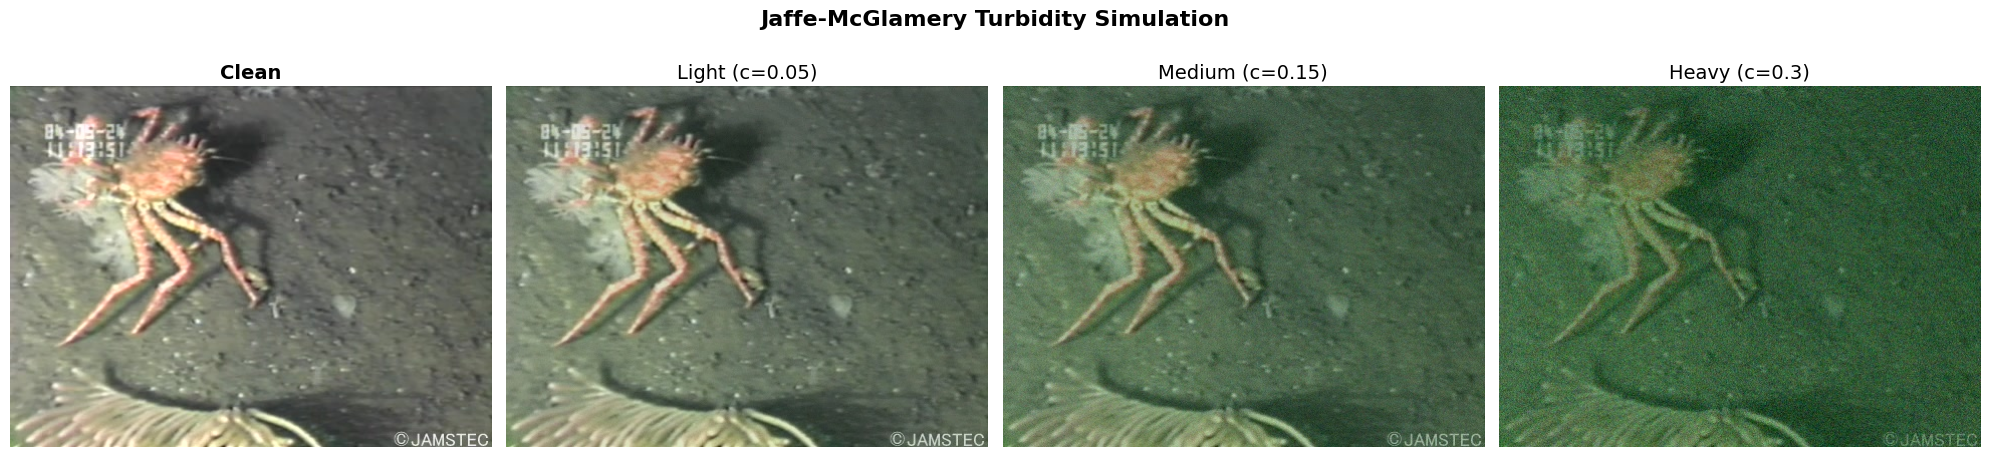

✓ Saved: results/figures/turbidity_levels.png


In [12]:
# ============================================================
# CELL 10: Visualize turbidity levels (paper figure)
# ============================================================
import cv2, matplotlib.pyplot as plt, os
from pathlib import Path

sample = sorted(Path("/content/turb-detr/data/processed/test/images").glob("*.jpg"))[5]  # pick 6th image

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
img = cv2.cvtColor(cv2.imread(str(sample)), cv2.COLOR_BGR2RGB)
axes[0].imshow(img); axes[0].set_title("Clean", fontsize=14, fontweight="bold"); axes[0].axis("off")

for i, (level, c) in enumerate([("light",0.05), ("medium",0.15), ("heavy",0.30)]):
    p = Path(f"/content/turb-detr/data/augmented/{level}/images") / sample.name
    img = cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB)
    axes[i+1].imshow(img); axes[i+1].set_title(f"{level.capitalize()} (c={c})", fontsize=14); axes[i+1].axis("off")

plt.suptitle("Jaffe-McGlamery Turbidity Simulation", fontsize=16, fontweight="bold")
plt.tight_layout()
os.makedirs("/content/turb-detr/results/figures", exist_ok=True)
plt.savefig("/content/turb-detr/results/figures/turbidity_levels.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved: results/figures/turbidity_levels.png")


In [13]:
# ============================================================
# CELL 11: Track B — Evaluate baseline on turbid test sets
# ============================================================
import yaml, os
from pathlib import Path
from ultralytics import RTDETR

BEST = "results/baseline_rtdetr_clean/weights/best.pt"
if not Path(BEST).exists():
    BEST = "results/baseline_rtdetr_clean/weights/last.pt"

LEVELS = ["light", "medium", "heavy"]
C_VALS = {"light": 0.05, "medium": 0.15, "heavy": 0.30}
turbid_results = {}

for level in LEVELS:
    # Create YAML
    aug_path = Path(f"/content/turb-detr/data/augmented/{level}").resolve()
    config = {
        "path": str(aug_path),
        "train": "images",
        "val": "images",
        "test": "images",
        "names": {0: "plastic", 1: "bio"},
    }
    yaml_path = f"/content/turb-detr/configs/datasets/trash_icra19_turbid_{level}.yaml"
    with open(yaml_path, "w") as f:
        yaml.dump(config, f, default_flow_style=False)

    print(f"\nEvaluating: {level} (c={C_VALS[level]})")
    try:
        model = RTDETR(BEST)
        res = model.val(data=yaml_path, split="test", device=0)
        turbid_results[level] = {
            "map50": res.box.map50,
            "map50_95": res.box.map,
            "precision": res.box.mp,
            "recall": res.box.mr,
            "ap_per_class": res.box.ap50,
        }
        print(f"  mAP@0.5: {res.box.map50:.4f}")
    except Exception as e:
        print(f"  ERROR: {e}")
        turbid_results[level] = {"map50": 0, "map50_95": 0, "precision": 0, "recall": 0, "ap_per_class": []}

print("\n✓ All turbid evaluations complete")



Evaluating: light (c=0.05)
Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
rt-detr-l summary: 502 layers, 31,987,850 parameters, 0 gradients, 103.4 GFLOPs


val: Scanning /content/turb-detr/data/augmented/light/labels... 1144 images, 24 backgrounds, 0 corrupt: 100%|██████████| 1144/1144 [00:00<00:00, 2245.36it/s]

val: New cache created: /content/turb-detr/data/augmented/light/labels.cache



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 72/72 [00:47<00:00,  1.50it/s]


                   all       1144       1333      0.967      0.931      0.974      0.758
               plastic        858        937      0.957      0.972      0.988      0.736
                   bio        322        396      0.978      0.889      0.959      0.779
Speed: 0.2ms preprocess, 36.6ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to runs/detect/val2
  mAP@0.5: 0.9735

Evaluating: medium (c=0.15)
Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
rt-detr-l summary: 502 layers, 31,987,850 parameters, 0 gradients, 103.4 GFLOPs


...

                   all       1144       1333      0.909      0.665      0.737      0.523
               plastic        858        937      0.855      0.785      0.835      0.547
                   bio        322        396      0.964      0.546      0.638      0.499
Speed: 0.2ms preprocess, 35.8ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to runs/detect/val3
  mAP@0.5: 0.7368

Evaluating: heavy (c=0.3)
Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
rt-detr-l summary: 502 layers, 31,987,850 parameters, 0 gradients, 103.4 GFLOPs


val: Scanning /content/turb-detr/data/augmented/heavy/labels... 1144 images, 24 backgrounds, 0 corrupt: 100%|██████████| 1144/1144 [00:01<00:00, 633.73it/s] 

val: New cache created: /content/turb-detr/data/augmented/heavy/labels.cache



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 72/72 [00:46<00:00,  1.54it/s]


                   all       1144       1333      0.532      0.161      0.149     0.0852
               plastic        858        937      0.412      0.259      0.215      0.106
                   bio        322        396      0.652     0.0631     0.0834     0.0641
Speed: 0.2ms preprocess, 36.4ms inference, 0.0ms loss, 0.3ms postprocess per image
Results saved to runs/detect/val4
  mAP@0.5: 0.1494

✓ All turbid evaluations complete


In [14]:
# ============================================================
# CELL 12: FINAL RESULTS TABLE — Your first publishable result
# ============================================================
import csv, os

os.makedirs("/content/turb-detr/results/tables", exist_ok=True)

print()
print("="*75)
print("  TURB-DETR MOTIVATION TABLE — RT-DETR-S Baseline on Trash-ICRA19")
print("  Classes: plastic + bio (ROV filtered out)")
print("="*75)
print(f"  {'Condition':<18} {'mAP@0.5':>10} {'mAP@.5:.95':>12} {'Prec':>8} {'Recall':>8} {'Drop':>8}")
print("-"*75)

# Clean
print(f"  {'Clean':<18} {clean_map50:>10.4f} {clean_map50_95:>12.4f} {clean_prec:>8.4f} {clean_rec:>8.4f} {'—':>8}")

# Turbid
rows = [{"condition": "clean", "map50": clean_map50, "map50_95": clean_map50_95,
         "precision": clean_prec, "recall": clean_rec, "drop_pct": 0}]

for level in ["light", "medium", "heavy"]:
    r = turbid_results[level]
    drop = clean_map50 - r["map50"]
    drop_pct = (drop / clean_map50 * 100) if clean_map50 > 0 else 0
    print(f"  {'Turbid-'+level:<18} {r['map50']:>10.4f} {r['map50_95']:>12.4f} {r['precision']:>8.4f} {r['recall']:>8.4f} {f'-{drop_pct:.1f}%':>8}")
    rows.append({"condition": f"turbid_{level}", "map50": r["map50"], "map50_95": r["map50_95"],
                 "precision": r["precision"], "recall": r["recall"], "drop_pct": drop_pct})

print("="*75)

# Per-class breakdown at heavy turbidity
print(f"\n  Per-class AP@0.5 (clean vs heavy):")
for i, name in enumerate(["plastic", "bio"]):
    c_ap = clean_ap_per_class[i] if i < len(clean_ap_per_class) else 0
    h_ap = turbid_results["heavy"]["ap_per_class"][i] if i < len(turbid_results["heavy"]["ap_per_class"]) else 0
    drop = c_ap - h_ap
    print(f"    {name}: {c_ap:.4f} → {h_ap:.4f} (drop: {drop:.4f})")

# Verdict
heavy_drop = rows[-1]["drop_pct"]
print()
if heavy_drop > 15:
    print(f"  ✓ SIGNIFICANT DROP ({heavy_drop:.1f}%). Research problem VALIDATED.")
    print(f"    → Proceed to SimAM implementation.")
elif heavy_drop > 10:
    print(f"  ⚠️ MODERATE DROP ({heavy_drop:.1f}%). Publishable — emphasize per-class analysis.")
else:
    print(f"  ✗ SMALL DROP ({heavy_drop:.1f}%). Check augmentation parameters.")
print("="*75)

# Save CSV
csv_path = "/content/turb-detr/results/tables/turbidity_collapse_baseline.csv"
with open(csv_path, "w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=["condition", "map50", "map50_95", "precision", "recall", "drop_pct"])
    w.writeheader()
    for row in rows:
        w.writerow({k: f"{v:.4f}" if isinstance(v, float) else v for k, v in row.items()})

print(f"\n  ✓ Saved: {csv_path}")
print()
print("  *** COPY THE TABLE ABOVE AND SEND IT BACK ***")



  TURB-DETR MOTIVATION TABLE — RT-DETR-S Baseline on Trash-ICRA19
  Classes: plastic + bio (ROV filtered out)
  Condition             mAP@0.5   mAP@.5:.95     Prec   Recall     Drop
---------------------------------------------------------------------------
  Clean                  0.9853       0.7669   0.9773   0.9462        —
  Turbid-light           0.9735       0.7577   0.9673   0.9307    -1.2%
  Turbid-medium          0.7368       0.5232   0.9095   0.6652   -25.2%
  Turbid-heavy           0.1494       0.0852   0.5319   0.1612   -84.8%

  Per-class AP@0.5 (clean vs heavy):
    plastic: 0.9925 → 0.2155 (drop: 0.7771)
    bio: 0.9781 → 0.0834 (drop: 0.8947)

  ✓ SIGNIFICANT DROP (84.8%). Research problem VALIDATED.
    → Proceed to SimAM implementation.

  ✓ Saved: /content/turb-detr/results/tables/turbidity_collapse_baseline.csv

  *** COPY THE TABLE ABOVE AND SEND IT BACK ***


In [15]:
# ============================================================
# CELL 13: Save results + weights to Drive
# ============================================================
import shutil
from pathlib import Path

SAVE = Path("/content/drive/MyDrive/turb_detr_results")
SAVE.mkdir(parents=True, exist_ok=True)

# Weights
for w in ["best.pt", "last.pt"]:
    src = Path(f"results/baseline_rtdetr_clean/weights/{w}")
    if src.exists():
        shutil.copy2(src, SAVE / f"baseline_rtdetr_s_{w}")
        print(f"✓ {w} → Drive")

# CSV
for f in Path("results/tables").glob("*.csv"):
    shutil.copy2(f, SAVE / f.name)
    print(f"✓ {f.name} → Drive")

# Figures
for f in Path("results/figures").glob("*.png"):
    shutil.copy2(f, SAVE / f.name)
    print(f"✓ {f.name} → Drive")

# Training curves
train_results = Path("results/baseline_rtdetr_clean/results.csv")
if train_results.exists():
    shutil.copy2(train_results, SAVE / "training_curves.csv")
    print("✓ training_curves.csv → Drive")

print(f"\nAll saved to: {SAVE}")
print("Session can safely disconnect now.")


✓ best.pt → Drive
✓ last.pt → Drive
✓ turbidity_collapse_baseline.csv → Drive
✓ turbidity_levels.png → Drive
✓ training_curves.csv → Drive

All saved to: /content/drive/MyDrive/turb_detr_results
Session can safely disconnect now.


## What happens next

**If heavy turbidity drop > 15%:**
→ Week 2: Implement SimAM injection into RT-DETR

**If drop is 10-15%:**
→ Analyze per-class results. Increase turbidity c values.

**If drop < 10%:**
→ Something is wrong with augmentation. Debug before proceeding.

**Send the table from Cell 12 back to Claude.**
